这个文件是，对rsm[1].data[left_index:right_index, 789:806, 1515:1526]这个小区域求多普勒速度图，对于contour在900以内的区域，认为是有jet物质的，采用云模型拟合，此外采用单高斯/矩方法。对于单云模型拟合得到约化卡方大于1.1的，采用双云拟合

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

__<font size=5 color=cyan>一: 用900contour圈出目标区域，生成jet_mask</font>__

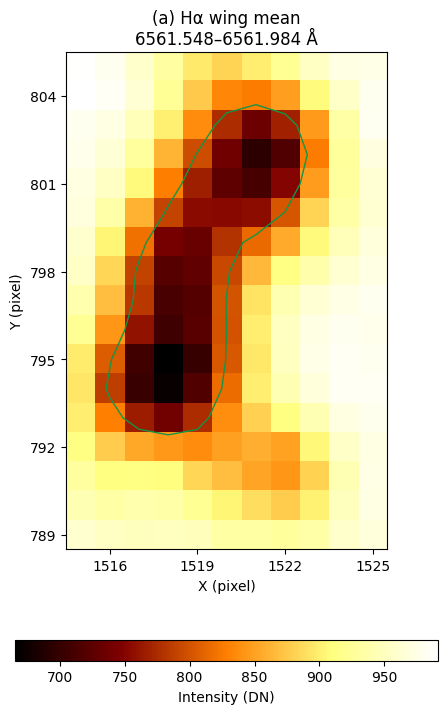

拟合波长：6561.548–6564.021 Å，共 52 点
I_cube 形状：(52, 17, 11)
jet_mask 形状：(17, 11)
jet 区域（≤800 DN）：38 个像素
区域外（>800 DN）：149 个像素
无效像素：0 个


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 数据准备：波长轴在前，空间轴依次为 y、x。
file_path = r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits"
rsm = fits.open(file_path)

left_index, right_index = 44, 96
y_start, y_stop = 789, 806
x_start, x_stop = 1515, 1526
contour_level = 800

header = rsm[1].header
lam00 = header["CRVAL3"] + np.arange(header["NAXIS3"]) * header["CDELT3"]
lam = lam00[left_index:right_index]

# 后续拟合使用的观测光谱和共同参考背景，均使用 30:108。
I_cube = np.asarray(rsm[1].data[left_index:right_index, y_start:y_stop, x_start:x_stop], dtype=float)
I0 = np.asarray(rsm[1].data[left_index:right_index, 797:826, 1540:1569], dtype=float).mean(axis=(1, 2))

# 显示图与区域选择始终使用原始波长索引 44:54，与拟合窗口独立。
ha_image = np.asarray(rsm[1].data[44:54, y_start:y_stop, x_start:x_stop], dtype=float).mean(axis=0)

x_pixels = np.arange(x_start, x_stop)
y_pixels = np.arange(y_start, y_stop)
X, Y = np.meshgrid(x_pixels, y_pixels)

# mask 的索引顺序为 [局部 y, 局部 x]，形状为 (17, 11)。
valid_mask = np.isfinite(ha_image)
jet_mask = valid_mask & (ha_image <= contour_level)
outside_mask = valid_mask & ~jet_mask

# 选中像素在原始 FITS 中的坐标，每行分别为 [y, x]。
jet_coords_yx = np.column_stack((Y[jet_mask], X[jet_mask]))
outside_coords_yx = np.column_stack((Y[outside_mask], X[outside_mask]))

# 选中区域的光谱：形状为 (波长点数, jet 像素数)。
jet_spectra = I_cube[:, jet_mask]

if not valid_mask.any():
    raise ValueError("强度图没有有效数据，请检查输入。")

# 绘图。
fig, ax = plt.subplots(figsize=(4.5, 7), constrained_layout=True)
cmap = plt.get_cmap("afmhot").copy()
cmap.set_bad("lightgray")
extent = (x_start - 0.5, x_stop - 0.5, y_start - 0.5, y_stop - 0.5)

im = ax.imshow(np.ma.masked_invalid(ha_image), origin="lower", 
               extent=extent, cmap=cmap, interpolation="nearest", aspect="equal")

# 只在强度范围跨过 900 时绘制等值线；开放曲线不会影响 jet_mask。
if ha_image[valid_mask].min() < contour_level < ha_image[valid_mask].max():
    ax.contour(X, Y, np.ma.masked_invalid(ha_image), levels=[contour_level], colors=["#159447"], linewidths=1.0)

ax.set(xlabel="X (pixel)", ylabel="Y (pixel)", title=f"(a) Hα wing mean\n{lam00[44]:.3f}–{lam00[53]:.3f} Å")
ax.set_xticks(np.arange(1516, 1526, 3))
ax.set_yticks(np.arange(789, 806, 3))
fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, label="Intensity (DN)")
plt.show()

print(f"拟合波长：{lam[0]:.3f}–{lam[-1]:.3f} Å，共 {lam.size} 点")
print(f"I_cube 形状：{I_cube.shape}")
print(f"jet_mask 形状：{jet_mask.shape}")
print(f"jet 区域（≤{contour_level} DN）：{jet_mask.sum()} 个像素")
print(f"区域外（>{contour_level} DN）：{outside_mask.sum()} 个像素")
print(f"无效像素：{(~valid_mask).sum()} 个")

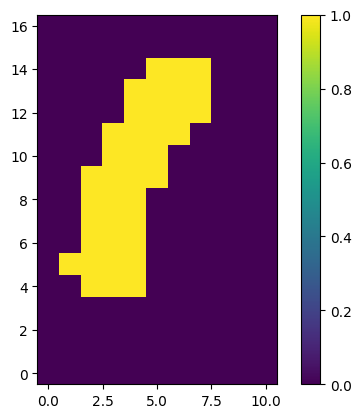

In [18]:
plt.imshow(jet_mask,origin='lower')
plt.colorbar()

__<font size=5 color=cyan>二：对jet_mask以外的区域和参考区域采用矩方法定线心</font>__

共同参考线心：6562.85214862 Å
拟合波长：6561.5480–6564.0207 Å，共 52 点
jet 内：38 个像素；jet 外：149 个像素


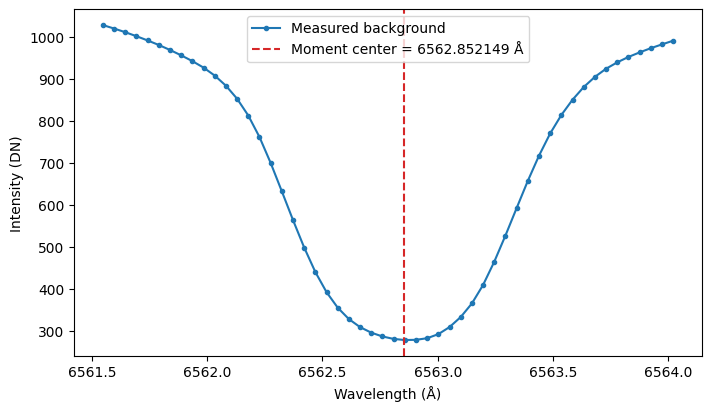

本次输出目录：C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hybrid_cloud\run_20260915_204941_009138


In [19]:
import importlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.patches import Patch
from joblib import Parallel, delayed, parallel_config

import single_cloud_pixel_fit as sc
import double_cloud_pixel_fit as dc

importlib.reload(sc)
importlib.reload(dc)

left_index, right_index = 44, 96
y_start, y_stop = 789, 806
x_start, x_stop = 1515, 1526
sigma = 22.42
chi2_threshold = 1.1
n_global_runs = 30
n_jobs = 8  # 可改为 16；这里在像素之间并行。
c = 299792.458

lam = np.asarray(lam00[left_index:right_index], dtype=float)
I0 = np.asarray(rsm[1].data[left_index:right_index, 797:826, 1540:1569], dtype=float).mean(axis=(1, 2))
I_cube = np.asarray(rsm[1].data[left_index:right_index, y_start:y_stop, x_start:x_stop], dtype=float)
ha_image = np.asarray(rsm[1].data[44:54, y_start:y_stop, x_start:x_stop], dtype=float).mean(axis=0)

n_wave, ny, nx = I_cube.shape
jet_mask = np.asarray(jet_mask, dtype=bool)
if jet_mask.shape != (ny, nx):
    raise ValueError("jet_mask 与当前空间区域形状不一致。")
if not np.all(np.isfinite(lam)) or not np.all(np.isfinite(I0)) or not np.all(np.isfinite(I_cube)):
    raise ValueError("输入存在无效光谱点，请先处理，以保证本次各像素使用相同波长点。")
if not np.all(np.diff(lam) > 0) or not np.allclose(np.diff(lam), np.diff(lam)[0], rtol=1e-4, atol=1e-10):
    raise ValueError("当前矩方法要求波长递增且近似等间隔。")
if np.max(I0) <= 0 or np.ptp(I0) == 0:
    raise ValueError("参考背景没有可用的吸收谱线。")

x_pixels = np.arange(x_start, x_stop)
y_pixels = np.arange(y_start, y_stop)
X, Y = np.meshgrid(x_pixels, y_pixels)
outside_mask = np.isfinite(ha_image) & ~jet_mask

# 吸收深度的一阶矩；背景和目标均使用同一种定义、同一段波长。
wave_anchor = np.mean(lam)
background_depth = 1.01 * np.max(I0) - I0
lam0 = wave_anchor + np.sum((lam - wave_anchor) * background_depth) / np.sum(background_depth)

moment_center = np.full((ny, nx), np.nan)
moment_velocity = np.full((ny, nx), np.nan)

for j, i in np.argwhere(outside_mask):
    sp = I_cube[:, j, i]
    if np.max(sp) <= 0 or np.ptp(sp) == 0:
        continue
    depth = 1.01 * np.max(sp) - sp
    moment_center[j, i] = wave_anchor + np.sum((lam - wave_anchor) * depth) / np.sum(depth)
    moment_velocity[j, i] = c * (moment_center[j, i] - lam0) / lam0

print(f"共同参考线心：{lam0:.8f} Å")
print(f"拟合波长：{lam[0]:.4f}–{lam[-1]:.4f} Å，共 {n_wave} 点")
print(f"jet 内：{jet_mask.sum()} 个像素；jet 外：{outside_mask.sum()} 个像素")

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(lam, I0, ".-", label="Measured background")
ax.axvline(lam0, color="tab:red", ls="--", label=f"Moment center = {lam0:.6f} Å")
ax.set(xlabel="Wavelength (Å)", ylabel="Intensity (DN)")
ax.legend()
plt.show()

# 独立输出目录，保存本次输入和区域选择。
run_dir = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hybrid_cloud") / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
(run_dir / "single_pixels").mkdir(parents=True, exist_ok=False)
(run_dir / "double_pixels").mkdir()

np.savez_compressed(run_dir / "input_data.npz", I_cube=I_cube, I0=I0, wavelength=lam, lam0=lam0, sigma=sigma, ha_image=ha_image, jet_mask=jet_mask, outside_mask=outside_mask, x_pixels=x_pixels, y_pixels=y_pixels)
print(f"本次输出目录：{run_dir}")

__<font size=5 color=cyan>三：对于jet内的区域，采用单云拟合</font>__

In [20]:
single_params = np.full((ny, nx, 4), np.nan)
single_model = np.full_like(I_cube, np.nan)
single_chi2 = np.full((ny, nx), np.nan)
single_redchi2 = np.full((ny, nx), np.nan)
single_success = np.zeros((ny, nx), dtype=bool)
single_results = {}

single_coords = [tuple(ji) for ji in np.argwhere(jet_mask)]

with parallel_config(backend="loky", inner_max_num_threads=1):
    jobs = (delayed(sc.fit_single_cloud_spectrum)(I_cube[:, j, i], lam, I0, lam0=lam0, n_global_runs=n_global_runs, base_seed=20260915 + (j * nx + i) * n_global_runs) for j, i in single_coords)
    with Parallel(n_jobs=n_jobs, return_as="generator", batch_size=1) as pool:
        for count, ((j, i), fit) in enumerate(zip(single_coords, pool(jobs)), 1):
            single_results[(y_start + j, x_start + i)] = fit
            single_params[j, i] = fit["params"]
            single_model[:, j, i] = fit["model"]
            single_success[j, i] = fit["success"]

            valid = fit["valid"]
            single_chi2[j, i] = np.sum(((I_cube[valid, j, i] - fit["model"][valid]) / sigma)**2)
            single_redchi2[j, i] = single_chi2[j, i] / (fit["n_valid"] - 4)

            stem = run_dir / "single_pixels" / f"fit_y{y_start + j:04d}_x{x_start + i:04d}"
            with open(stem.with_suffix(".pkl"), "wb") as f:
                pickle.dump(fit, f, protocol=pickle.HIGHEST_PROTOCOL)
            np.savez_compressed(stem.with_suffix(".npz"), params=fit["params"], param_names=np.array(sc.PARAM_NAMES), wavelength=lam, intensity=I_cube[:, j, i], I0=I0, model=fit["model"], lam0=lam0, sigma=sigma, chi2=single_chi2[j, i], reduced_chi2=single_redchi2[j, i], success=fit["success"], near_bound=fit["near_bound"])

            print(f"单云 [{count}/{len(single_coords)}] y={y_start + j}, x={x_start + i}, v={fit['params'][1]:.3f} km/s, reduced chi2={single_redchi2[j, i]:.4g}, converged={fit['success']}")

# 第一张速度图保留“单云＋矩方法”的结果，后续不被双云覆盖。
velocity_stage1 = moment_velocity.copy()
velocity_stage1[jet_mask] = single_params[..., 1][jet_mask]
velocity_stage1[jet_mask & ~single_success] = np.nan

# 按你的阈值选择双云拟合位置。
double_mask = jet_mask & np.isfinite(single_redchi2) & (single_redchi2 > chi2_threshold)

np.savez_compressed(run_dir / "single_stage_maps.npz", params=single_params, model=single_model, chi2=single_chi2, reduced_chi2=single_redchi2, success=single_success, moment_center=moment_center, moment_velocity=moment_velocity, velocity_stage1=velocity_stage1, double_mask=double_mask)

print(f"单云收敛：{np.count_nonzero(jet_mask & single_success)}/{jet_mask.sum()}")
print(f"约化卡方 > {chi2_threshold}，进入双云拟合：{double_mask.sum()} 个像素")

单云 [1/38] y=793, x=1517, v=-8.616 km/s, reduced chi2=1.203, converged=True
单云 [2/38] y=793, x=1518, v=-10.861 km/s, reduced chi2=0.8109, converged=True
单云 [3/38] y=793, x=1519, v=-5.099 km/s, reduced chi2=1.066, converged=True
单云 [4/38] y=794, x=1516, v=-9.595 km/s, reduced chi2=0.9977, converged=True
单云 [5/38] y=794, x=1517, v=-14.033 km/s, reduced chi2=0.6172, converged=True
单云 [6/38] y=794, x=1518, v=-15.638 km/s, reduced chi2=0.326, converged=True
单云 [7/38] y=794, x=1519, v=-10.192 km/s, reduced chi2=0.6156, converged=True
单云 [8/38] y=795, x=1517, v=-13.102 km/s, reduced chi2=0.2418, converged=True
单云 [9/38] y=795, x=1518, v=-15.824 km/s, reduced chi2=0.1406, converged=True
单云 [10/38] y=795, x=1519, v=-12.861 km/s, reduced chi2=0.3837, converged=True
单云 [11/38] y=796, x=1517, v=-8.701 km/s, reduced chi2=0.1728, converged=True
单云 [12/38] y=796, x=1518, v=-13.061 km/s, reduced chi2=0.1474, converged=True
单云 [13/38] y=796, x=1519, v=-12.786 km/s, reduced chi2=0.2686, converged=True
单云

__<font size=5 color=cyan>四：对于单云但是约化卡方大于1.1的区域用双云</font>__

In [21]:
double_params = np.full((ny, nx, 8), np.nan)
double_model = np.full_like(I_cube, np.nan)
double_chi2 = np.full((ny, nx), np.nan)
double_redchi2 = np.full((ny, nx), np.nan)
double_success = np.zeros((ny, nx), dtype=bool)
double_results = {}

double_coords = [tuple(ji) for ji in np.argwhere(double_mask)]

with parallel_config(backend="loky", inner_max_num_threads=1):
    jobs = (delayed(dc.fit_double_cloud_spectrum)(I_cube[:, j, i], lam, I0, lam0=lam0, n_global_runs=n_global_runs, base_seed=20270915 + (j * nx + i) * n_global_runs) for j, i in double_coords)
    with Parallel(n_jobs=n_jobs, return_as="generator", batch_size=1) as pool:
        for count, ((j, i), fit) in enumerate(zip(double_coords, pool(jobs)), 1):
            double_results[(y_start + j, x_start + i)] = fit
            double_params[j, i] = fit["params"]
            double_model[:, j, i] = fit["model"]
            double_success[j, i] = fit["success"]

            valid = fit["valid"]
            double_chi2[j, i] = np.sum(((I_cube[valid, j, i] - fit["model"][valid]) / sigma)**2)
            double_redchi2[j, i] = double_chi2[j, i] / (fit["n_valid"] - 8)

            stem = run_dir / "double_pixels" / f"fit_y{y_start + j:04d}_x{x_start + i:04d}"
            with open(stem.with_suffix(".pkl"), "wb") as f:
                pickle.dump(fit, f, protocol=pickle.HIGHEST_PROTOCOL)
            np.savez_compressed(stem.with_suffix(".npz"), params=fit["params"], param_names=np.array(dc.PARAM_NAMES), wavelength=lam, intensity=I_cube[:, j, i], I0=I0, model=fit["model"], lam0=lam0, sigma=sigma, chi2=double_chi2[j, i], reduced_chi2=double_redchi2[j, i], success=fit["success"], near_bound=fit["near_bound"])

            print(f"双云 [{count}/{len(double_coords)}] y={y_start + j}, x={x_start + i}, vL={fit['params'][2]:.3f}, vU={fit['params'][3]:.3f} km/s, reduced chi2={double_redchi2[j, i]:.4g}, converged={fit['success']}")

vL_map = double_params[..., 2].copy()
vU_map = double_params[..., 3].copy()
vL_map[~double_success] = np.nan
vU_map[~double_success] = np.nan

result_hybrid = dict(output_dir=run_dir, wavelength=lam, lam0=lam0, I0=I0, I_cube=I_cube, sigma=sigma, chi2_threshold=chi2_threshold, n_global_runs=n_global_runs, ha_image=ha_image, jet_mask=jet_mask, outside_mask=outside_mask, double_mask=double_mask, x_pixels=x_pixels, y_pixels=y_pixels, moment_center=moment_center, moment_velocity=moment_velocity, velocity_stage1=velocity_stage1, single_params=single_params, single_chi2=single_chi2, single_redchi2=single_redchi2, single_success=single_success, single_results=single_results, double_params=double_params, double_chi2=double_chi2, double_redchi2=double_redchi2, double_success=double_success, double_results=double_results, vL=vL_map, vU=vU_map, reference_method="absorption-depth first moment; depth=1.01*max(I)-I")

with open(run_dir / "result_hybrid.pkl", "wb") as f:
    pickle.dump(result_hybrid, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"双云收敛：{np.count_nonzero(double_mask & double_success)}/{double_mask.sum()}")
print(f"完整结果已保存：{run_dir / 'result_hybrid.pkl'}")

双云 [1/1] y=793, x=1517, vL=0.772, vU=-19.017 km/s, reduced chi2=0.03094, converged=True
双云收敛：1/1
完整结果已保存：C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hybrid_cloud\run_20260915_204941_009138\result_hybrid.pkl


In [3]:
single_values = single_redchi2[jet_mask & np.isfinite(single_redchi2)]
double_values = double_redchi2[double_mask & np.isfinite(double_redchi2)]

for name, values in [("单云", single_values), ("双云", double_values)]:
    if values.size:
        print(f"{name}约化卡方：像素数={values.size}，最小值={values.min():.6g}，最大值={values.max():.6g}，中位数={np.median(values):.6g}，平均值={values.mean():.6g}")
    else:
        print(f"{name}：没有可统计的约化卡方。")

print(f"单云未收敛像素数：{np.count_nonzero(jet_mask & ~single_success)}")
print(f"双云未收敛像素数：{np.count_nonzero(double_mask & ~double_success)}")

velocity_limit = 70

unused_color = "#bdbdbd"

velocity_cmap = plt.get_cmap("bwr").resampled(257)
velocity_cmap.set_bad(unused_color)
chi2_cmap = plt.get_cmap("YlOrRd").copy()
chi2_cmap.set_bad(unused_color)

velocity_norm = TwoSlopeNorm(vmin=-velocity_limit, vcenter=0, vmax=velocity_limit)

# 下限保持 0，上限分别使用各自实际数据的最大值。
# 没有结果时使用占位范围；全零时避免上下限相同。
single_vmax = max(float(single_values.max()), 1e-12) if single_values.size else 1.0
#single_vmax=2
double_vmax = max(float(double_values.max()), 1e-12) if double_values.size else 1.0

single_chi2_norm = Normalize(vmin=0, vmax=single_vmax)
double_chi2_norm = Normalize(vmin=0, vmax=double_vmax)

extent = (x_start - 0.5, x_stop - 0.5, y_start - 0.5, y_stop - 0.5)
has_contour = np.nanmin(ha_image) < 800 < np.nanmax(ha_image)

# 第一张：单云＋矩方法速度，以及单云约化卡方。
fig1, axes1 = plt.subplots(1, 2, figsize=(10, 7), sharex=True, sharey=True, constrained_layout=True)

panels1 = [
    (velocity_stage1, velocity_cmap, velocity_norm, "(a) Single cloud + moment", "Velocity (km/s)", "both"),
    (single_redchi2, chi2_cmap, single_chi2_norm, f"(b) Single-cloud reduced chi-square\nN={n_wave}, p=4", r"Reduced $\chi^2$", "neither")
]

for ax, (values, cmap, norm, title, label, extend) in zip(axes1, panels1):
    im = ax.imshow(np.ma.masked_invalid(values), origin="lower", extent=extent, cmap=cmap, norm=norm, interpolation="nearest", aspect="equal")
    if has_contour:
        ax.contour(X, Y, ha_image, levels=[800], colors="#444444", linewidths=0.8)
    jy, ix = np.where(jet_mask & ~single_success)
    if jy.size:
        ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="#d000ff", s=30, linewidths=1)
    ax.set(title=title, xlabel="X (pixel)", ylabel="Y (pixel)")
    fig1.colorbar(im, ax=ax, label=label, extend=extend, shrink=0.85)

axes1[1].legend(handles=[Patch(facecolor=unused_color, label="No single-cloud fit")], loc="upper left", fontsize=8)
fig1.savefig(run_dir / "single_plus_moment_maps.png", dpi=300, bbox_inches="tight")
fig1.savefig(run_dir / "single_plus_moment_maps.pdf", bbox_inches="tight")
plt.show()

# 第二张：双云下层速度、上层速度、约化卡方。
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

panels2 = [
    (vL_map, velocity_cmap, velocity_norm, "(a) Lower-cloud velocity", "Velocity (km/s)", "both"),
    (vU_map, velocity_cmap, velocity_norm, "(b) Upper-cloud velocity", "Velocity (km/s)", "both"),
    (double_redchi2, chi2_cmap, double_chi2_norm, f"(c) Double-cloud reduced chi-square\nN={n_wave}, p=8", r"Reduced $\chi^2$", "neither")
]

for ax, (values, cmap, norm, title, label, extend) in zip(axes2, panels2):
    im = ax.imshow(np.ma.masked_invalid(values), origin="lower", extent=extent, cmap=cmap, norm=norm, interpolation="nearest", aspect="equal")
    if has_contour:
        ax.contour(X, Y, ha_image, levels=[800], colors="#444444", linewidths=0.8)
    jy, ix = np.where(double_mask & ~double_success)
    if jy.size:
        ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="#d000ff", s=30, linewidths=1)
    ax.set(title=title, xlabel="X (pixel)", ylabel="Y (pixel)")
    fig2.colorbar(im, ax=ax, label=label, extend=extend, shrink=0.85)

axes2[2].legend(handles=[Patch(facecolor=unused_color, label="No double-cloud fit")], loc="upper left", fontsize=8)
fig2.savefig(run_dir / "double_cloud_maps.png", dpi=300, bbox_inches="tight")
fig2.savefig(run_dir / "double_cloud_maps.pdf", bbox_inches="tight")
plt.show()

单云约化卡方：像素数=38，最小值=0.111041，最大值=1.20265，中位数=0.371496，平均值=0.456038
双云约化卡方：像素数=1，最小值=0.0309401，最大值=0.0309401，中位数=0.0309401，平均值=0.0309401
单云未收敛像素数：0
双云未收敛像素数：0


NameError: name 'x_start' is not defined

<font color=cyan>这一段是重新读取画图</font>

波长点数：52；参考线心：6562.85214862 Å；误差：22.42 DN
单云区域：38 个像素；双云区域：1 个像素
单云约化卡方：N=38，最小值=0.111041，最大值=1.20265，中位数=0.371496，平均值=0.456038
双云约化卡方：N=1，最小值=0.0309401，最大值=0.0309401，中位数=0.0309401，平均值=0.0309401
单云未收敛：0
双云未收敛：0


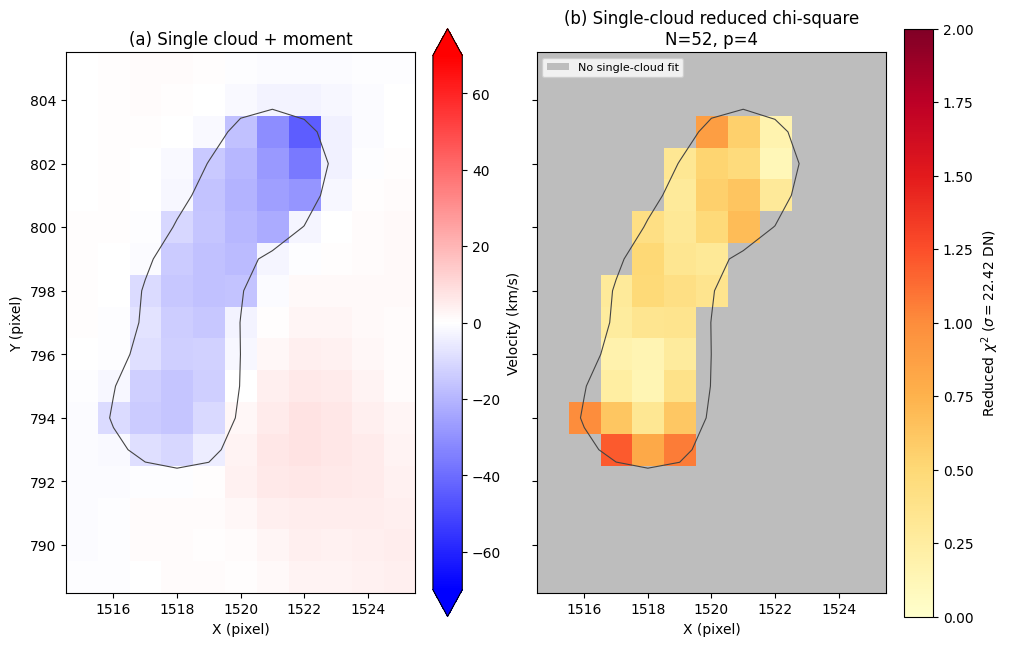

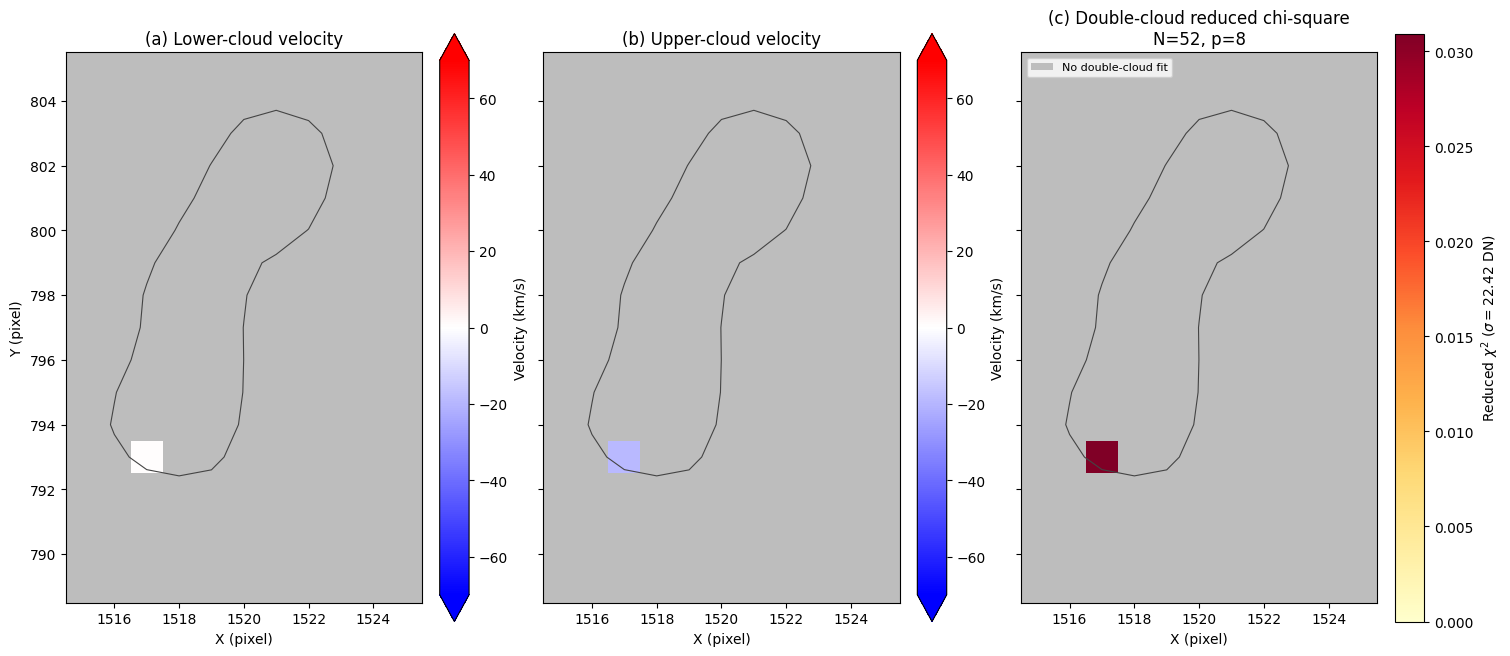

In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Patch

# 读取完整结果。
run_dir = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hybrid_cloud\run_20260915_204941_009138")
with open(run_dir / "result_hybrid.pkl", "rb") as f:
    result = pickle.load(f)

wave = result["wavelength"]
sigma = float(result["sigma"])
ha_image = result["ha_image"]
jet_mask = np.asarray(result["jet_mask"], dtype=bool)
double_mask = np.asarray(result["double_mask"], dtype=bool)
single_success = np.asarray(result["single_success"], dtype=bool)
double_success = np.asarray(result["double_success"], dtype=bool)
x_pixels = result["x_pixels"]
y_pixels = result["y_pixels"]
X, Y = np.meshgrid(x_pixels, y_pixels)

velocity_stage1 = np.asarray(result["velocity_stage1"], dtype=float).copy()
vL_map = np.asarray(result["vL"], dtype=float).copy()
vU_map = np.asarray(result["vU"], dtype=float).copy()
single_redchi2 = np.where(jet_mask, result["single_redchi2"], np.nan)
double_redchi2 = np.where(double_mask, result["double_redchi2"], np.nan)

# 未收敛的速度不显示；卡方诊断值保留，绘图时标记。
velocity_stage1[jet_mask & ~single_success] = np.nan
vL_map[~double_mask | ~double_success] = np.nan
vU_map[~double_mask | ~double_success] = np.nan

print(f"波长点数：{len(wave)}；参考线心：{result['lam0']:.8f} Å；误差：{sigma} DN")
print(f"单云区域：{jet_mask.sum()} 个像素；双云区域：{double_mask.sum()} 个像素")

# 统计实际拟合区域内的有限卡方值，灰色区域不参与。
single_values = single_redchi2[np.isfinite(single_redchi2)]
double_values = double_redchi2[np.isfinite(double_redchi2)]

for name, values in [("单云", single_values), ("双云", double_values)]:
    if values.size:
        print(f"{name}约化卡方：N={values.size}，最小值={values.min():.6g}，最大值={values.max():.6g}，中位数={np.median(values):.6g}，平均值={values.mean():.6g}")
    else:
        print(f"{name}：没有可统计的结果。")

print(f"单云未收敛：{np.count_nonzero(jet_mask & ~single_success)}")
print(f"双云未收敛：{np.count_nonzero(double_mask & ~double_success)}")

# 显示设置。
velocity_limit = 70  # 所有速度图使用相同的对称色标，0 为白色。
contour_level = 800  # 已核对本次保存的 jet_mask 与这个阈值一致。
save_figures = True
unused_color = "#bdbdbd"

velocity_cmap = plt.get_cmap("bwr").resampled(257)
velocity_cmap.set_bad(unused_color)
chi2_cmap = plt.get_cmap("YlOrRd").copy()
chi2_cmap.set_bad(unused_color)

velocity_norm = TwoSlopeNorm(vmin=-velocity_limit, vcenter=0, vmax=velocity_limit)

# 单云、双云的卡方上限各自取实际最大值。
single_vmax = max(float(single_values.max()), 1e-12) if single_values.size else 1.0
double_vmax = max(float(double_values.max()), 1e-12) if double_values.size else 1.0
single_chi2_norm = Normalize(vmin=0, vmax=2)
#single_chi2_norm = Normalize(vmin=0, vmax=single_vmax)
double_chi2_norm = Normalize(vmin=0, vmax=double_vmax)

extent = (x_pixels[0] - 0.5, x_pixels[-1] + 0.5, y_pixels[0] - 0.5, y_pixels[-1] + 0.5)
chi2_label = rf"Reduced $\chi^2$ ($\sigma={sigma:g}$ DN)"
has_contour = np.nanmin(ha_image) < contour_level < np.nanmax(ha_image)

# 每项依次为：数据、色表、归一化、标题、colorbar 标签、colorbar 端点。
panels_single = [
    (velocity_stage1, velocity_cmap, velocity_norm, "(a) Single cloud + moment", "Velocity (km/s)", "both"),
    (single_redchi2, chi2_cmap, single_chi2_norm, f"(b) Single-cloud reduced chi-square\nN={len(wave)}, p=4", chi2_label, "neither")
]

panels_double = [
    (vL_map, velocity_cmap, velocity_norm, "(a) Lower-cloud velocity", "Velocity (km/s)", "both"),
    (vU_map, velocity_cmap, velocity_norm, "(b) Upper-cloud velocity", "Velocity (km/s)", "both"),
    (double_redchi2, chi2_cmap, double_chi2_norm, f"(c) Double-cloud reduced chi-square\nN={len(wave)}, p=8", chi2_label, "neither")
]

figure_groups = [
    ("single_plus_moment_replot", panels_single, jet_mask & ~single_success, "No single-cloud fit"),
    ("double_cloud_replot", panels_double, double_mask & ~double_success, "No double-cloud fit")
]

figures = {}

for filename, panels, failed_mask, legend_label in figure_groups:
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 7), sharex=True, sharey=True, constrained_layout=True)

    for ax, (values, cmap, norm, title, label, extend) in zip(axes, panels):
        im = ax.imshow(np.ma.masked_invalid(values), origin="lower", extent=extent, cmap=cmap, norm=norm, interpolation="nearest", aspect="equal")

        if has_contour:
            ax.contour(X, Y, ha_image, levels=[contour_level], colors="#444444", linewidths=0.8)

        jy, ix = np.where(failed_mask)
        if jy.size:
            ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="#d000ff", s=30, linewidths=1)

        ax.set(title=title, xlabel="X (pixel)")
        fig.colorbar(im, ax=ax, label=label, extend=extend, shrink=0.85)

    axes[0].set_ylabel("Y (pixel)")
    axes[-1].legend(handles=[Patch(facecolor=unused_color, label=legend_label)], loc="upper left", fontsize=8)
    figures[filename] = fig

    if save_figures:
        fig.savefig(run_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
        fig.savefig(run_dir / f"{filename}.pdf", bbox_inches="tight")

    plt.show()